<h2></h2>
<center><b>

# Compute Graph, Autograd and Backprop
<h3>Fall 2026</h3>
<h3>CSC-372 Project Part 5</h3></b>

</center>

<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/Project5.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


<img src="Project5.gif" width="100%" style="filter: invert(1);">


Modern deep learning frameworks such as PyTorch make it remarkably easy to define a neural network, compute a loss, call `loss.backward()`, and update the model's parameters.

But what exactly happens when we call backward()?

In this assignment, you will find out by <font color="violet">building a small automatic differentiation (autograd) engine from scratch</font>. By the end of the assignment, you will have implemented the essential machinery that allows neural networks to learn.

Your implementation will begin with a simple <font color="violet">Scalar object</font> representing a single scalar number. Unlike an ordinary Python number, however, a Scalar <font color="violet">will remember how it was computed</font>. As you perform arithmetic operations, your program <font color="violet">will construct a computational graph connecting values and operations</font>.

You will then implement the derivatives associated with these operations and use the chain rule to propagate gradients backward through the graph. This will allow you to implement your own version of:

`loss.backward()`

Once your autograd engine is working, in Project Part 6 we will use it to <font color="violet">build the basic components of a neural network—including neurons, layers, and a multilayer perceptron (MLP). Then, we will train your network using gradient descent</font>.

The goal is not to build a fast or production-ready deep learning framework. Instead, the goal is to understand the relatively small set of ideas underneath frameworks such as PyTorch.

<br/>
<hr/>
<br/>

# **Q1**. Building the `Scalar` Class

We will begin by creating the fundamental building block of our autograd engine: the `Scalar` class.

The `Scalar` class will be the **principal data structure** used throughout this assignment. You can think of it as playing a role similar to:

- a `Tensor` in PyTorch, or
- a `DataFrame` in pandas.

Just as most operations in PyTorch operate on and return `Tensor` objects, the operations in our autograd engine will operate on and return `Scalar` objects.

There is one important simplification: while a PyTorch `Tensor` can contain scalars, vectors, matrices, or higher-dimensional arrays, our `Scalar` object will contain only **a single scalar number**.

However, a `Scalar` will store more than just that number. It will also keep track of information that allows us to reconstruct **how the value was computed**. This will eventually allow us to traverse the computation backward and calculate gradients.



### 1.1. Define the `Scalar` Class

Create a class called `Scalar`. Each `Scalar` object should store the following information:

- **`data`** — the scalar numerical value represented by this object.
- **`grad`** — the derivative of the final output with respect to this value. Initialize this to `0.0`.
- **`_prev`** — the `Scalar` objects that were used to produce this value. Store these as a `set`.
- **`_op`** — a string describing the operation that produced this value, such as `"+"` or `"*"`.
- **`label`** — an optional human-readable name that will make computational graphs easier to inspect.

Your constructor should support creating objects such as:

```python
a = Scalar(2.0, label="a")
b = Scalar(-3.0, label="b")
```

At this point, `a` and `b` are **leaf nodes**. They contain values, but they were not produced by performing an operation on other `Scalar` objects.

---


In [ ]:
class Scalar:
  pass

In [ ]:
# Test code

a = Scalar(2.0, label="a")

assert a.data == 2.0
assert a.grad == 0.0
assert a.label == "a"
assert a._prev == set()
assert a._op == ""

b = Scalar(-3.5)

assert b.data == -3.5
assert b.grad == 0.0
assert b._prev == set()
assert b._op == ""

print("1.1 complete!")

Step 1 complete!



### 1.2. Supporting Addition

Next, we want our `Scalar` objects to behave like numbers. In particular, we would like to write:

```python
c = a + b
```

To make the `+` operator work with `Scalar` objects, implement the `__add__` method.

The result of `a + b` should be a **new `Scalar` object** whose `data` contains:

```python
a.data + b.data
```

But storing the numerical result is only half of the job.

The new `Scalar` must also remember **how it was created**. This is where the `_prev` and `_op` attributes become important.

For the operation:

```python
c = a + b
```

`c` should record:

```text
c.data  → the result of a.data + b.data
c._prev → {a, b}
c._op   → "+"
```

The `_prev` attribute tells us **which `Scalar` objects were the inputs to this computation**, while `_op` tells us **which operation was applied to those inputs**.

Together, these attributes allow us to reconstruct the computational graph:

```text
a ──┐
    + ──> c
b ──┘
```

Notice that we do not need to explicitly create a separate graph object. **The graph is constructed automatically as `Scalar` objects perform operations on one another.**

For example, if we subsequently write:

```python
d = c + a
```

then `d` should remember that it was created from `c` and `a`, while `c` already remembers that it was created from `a` and `b`.

We therefore have enough information stored inside the `Scalar` objects themselves to reconstruct the entire chain of computation.

---


In [ ]:
# Copy your previous implementation into this cell, then extend it with 1.2.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(2.0, label="a")
b = Scalar(3.0, label="b")

c = a + b

assert isinstance(c, Scalar)
assert c.data == 5.0
assert c._op == "+"
assert c._prev == {a, b}

assert a.data == 2.0
assert b.data == 3.0
assert a._prev == set()
assert b._prev == set()

a = Scalar(1.0)
b = Scalar(2.0)
c = Scalar(4.0)

d = a + b
e = d + c

assert d.data == 3.0
assert d._prev == {a, b}

assert e.data == 7.0
assert e._prev == {d, c}

print("Step 2 passed!")


### 1.3. Supporting Multiplication

Implement the same behavior for multiplication by defining `__mul__`.

For example:

```python
d = a * b
```

should create a new `Scalar` whose numerical value is:

```python
a.data * b.data
```

and which records:

```text
d._prev → {a, b}
d._op   → "*"
```

Again, performing the operation should both **compute a value** and **add a new node to the computational graph**.

---

In [ ]:
# Copy your previous implementation into this cell, then extend it with 1.3.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
# Test code

a = Scalar(2.0, label="a")
b = Scalar(-3.0, label="b")

c = a * b

assert isinstance(c, Scalar)
assert c.data == -6.0
assert c._op == "*"
assert c._prev == {a, b}

a = Scalar(2.0, label="a")
b = Scalar(-3.0, label="b")
c = Scalar(10.0, label="c")

e = a * b
d = e + c

assert e.data == -6.0
assert e._op == "*"
assert e._prev == {a, b}

assert d.data == 4.0
assert d._op == "+"
assert d._prev == {e, c}

print("Step 3 passed!")



### 1.4. Inspecting Scalars

Implement `__repr__` so that printing a `Scalar` gives useful information.

For example:

```python
a = Scalar(2.0)
print(a)
```

might produce:

```text
Scalar(data=2.0)
```

The exact formatting is up to you, but it should make debugging your autograd engine easier.

In [ ]:
# Copy your previous implementation into this cell, then extend it with 1.4.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
# Test
a = Scalar(data=2.0)

representation = repr(a)

assert isinstance(representation, str)
assert "2.0" in representation

print("Step 4 passed!")



### 1.5. Test Your Implementation

Once you have implemented the class, the following code should work:

```python
a = Scalar(2.0, label="a")
b = Scalar(-3.0, label="b")
c = Scalar(10.0, label="c")

e = a * b
d = e + c
```

Inspect the values of:

```python
e.data
e._prev
e._op

d.data
d._prev
d._op
```

From this information, you should be able to reconstruct the computation:

```text
a ──┐
    * ──> e ──┐
b ──┘         + ──> d
          c ──┘
```

At this stage, **do not implement backpropagation or calculate any derivatives**. Your goal is simply to make every computation produce a `Scalar` that stores its numerical result **and remembers how that result was produced**.

In [ ]:
a = Scalar(2.0, label="a")
b = Scalar(-3.0, label="b")
c = Scalar(10.0, label="c")
f = Scalar(-2.0, label="f")

e = a * b
d = e + c
L = d * f

assert e.data == -6.0
assert d.data == 4.0
assert L.data == -8.0

assert e._prev == {a, b}
assert d._prev == {e, c}
assert L._prev == {d, f}

assert e._op == "*"
assert d._op == "+"
assert L._op == "*"

print("All Scalar class tests passed!")

---

# **Q2**. Local Gradients and Chain Rule

In 1, our `Scalar` objects learned how to **remember the computation that produced them**. We can now build a computational graph such as:

```text
a ──┐
    * ──> e ──┐
b ──┘         + ──> d
          c ──┘
```

However, our `Scalar` class does not yet know how to compute gradients.

Our next goal is to teach each operation how to propagate a gradient **backward to its inputs**.

## 2.1. Backpropagating Through Addition

Every `Scalar` should have a `_backward` function.

When a `Scalar` is first created, `_backward` should be a function that does nothing.

For example, a leaf node such as:

```python
a = Scalar(2.0)
```

was not produced by an operation, so there is nothing before `a` to propagate a gradient to.

Add a `_backward` function to your `Scalar` class that initially does nothing.



Consider:

```python
a = Scalar(2.0)
b = Scalar(3.0)

c = a + b
```

Mathematically,

$$c = a + b$$

so the local derivatives are:

$$\frac{\partial c}{\partial a}=1$$

and

$$\frac{\partial c}{\partial b}=1$$

Suppose that during backpropagation we already know `c.grad`, which represents:

$$\frac{\partial L}{\partial c}$$

where $L$ is the final output or loss.

Using the chain rule:

$$
\frac{\partial L}{\partial a}
=
\frac{\partial L}{\partial c}
\frac{\partial c}{\partial a}
$$

and similarly for $b$.

Modify `__add__` so that the `Scalar` it creates has a `_backward` function capable of propagating `out.grad` to the inputs of the addition.

Remember that gradients should be **accumulated**, rather than overwritten.





In [ ]:
# Copy your previous implementation into this cell, then extend it with 2.1.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(2.0)

assert callable(a._backward)

# Calling it should not produce an error.
a._backward()

print("Step 1 passed!")

In [ ]:
a = Scalar(2.0)
b = Scalar(3.0)

c = a + b

c.grad = 4.0  # manually / artificially setting gradient
c._backward()

assert a.grad == 4.0
assert b.grad == 4.0

print("Addition backward test passed!")


Why `4.0`?

Because:

$$
\frac{\partial L}{\partial a}
=
\underbrace{\frac{\partial L}{\partial c}}_{4}
\underbrace{\frac{\partial c}{\partial a}}_{1}
=4
$$



---

## 2.2. Backpropagating Through Multiplication

Now consider:

```python
a = Scalar(2.0)
b = Scalar(3.0)

c = a * b
```

Mathematically,

$$c=ab$$

The local derivatives are:

$$\frac{\partial c}{\partial a}=b$$

and

$$\frac{\partial c}{\partial b}=a$$

Modify `__mul__` so that its output has a `_backward` function that propagates the output gradient to both inputs.

Again, use the chain rule and remember to **accumulate** gradients.



In [ ]:
# Copy your previous implementation into this cell, then extend it with 2.2.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(2.0)
b = Scalar(3.0)

c = a * b

c.grad = 4.0
c._backward()

assert a.grad == 12.0
assert b.grad == 8.0

print("Multiplication backward test passed!")


The expected gradients are:

$$\frac{\partial L}{\partial a}=4(3)=12$$

and

$$\frac{\partial L}{\partial b}=4(2)=8$$

---



## 2.3. Why Gradients Must Accumulate

A value may influence the final output through **more than one path**.

Consider:

```python
a = Scalar(3.0)

b = a + a
```

Because $b=2a$,

$$\frac{\partial b}{\partial a}=2$$

Your implementation should therefore accumulate both contributions to `a.grad`.


In [ ]:
# Copy your previous implementation into this cell, then extend it with 2.3.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(3.0)

b = a + a

b.grad = 1.0
b._backward()

assert a.grad == 2.0

print("Gradient accumulation test passed!")



If this test fails, check whether your `_backward` functions are **adding to** gradients or replacing them.

---

At this point, individual operations know how to propagate gradients backward.

In [ ]:
a = Scalar(2.0)
b = Scalar(3.0)

c = a * b
d = c + a

# d = ab + a

d.grad = 1.0

# Manually walk backward through the graph
d._backward()
c._backward()

assert d.grad == 1.0
assert c.grad == 1.0
assert a.grad == 4.0
assert b.grad == 2.0

print("Part 2 passed!")

Here,

$$d = ab + a$$

so:

$$
\frac{\partial d}{\partial a}
=
b+1
=
4
$$

and

$$
\frac{\partial d}{\partial b}
=
a
=
2
$$

Notice something important: **we still had to decide ourselves that `d._backward()` should be called before `c._backward()`.**

Our individual operations know how to differentiate themselves, but our autograd engine does not yet know how to automatically traverse an entire computational graph.

That is the problem we will solve next.

---

# **Q3**. Implementing `backward()`

In Part 2, each operation learned how to propagate gradients to its immediate inputs.

However, we still had to manually call:

```python
d._backward()
c._backward()
```

For a neural network containing thousands or millions of operations, manually determining the correct order would obviously be impossible.

Our goal is now to implement:

```python
d.backward()
```

and have our autograd engine automatically propagate gradients through the entire computational graph.

**Why Does Order Matter?**

Consider:

```text
a ──┐
    * ──> c ──┐
b ──┘         + ──> d
          a ──┘
```

Before we can propagate the gradient from `c` to `a` and `b`, we first need to know the gradient of `c`.

Therefore, backpropagation must process nodes in an order such that a node receives all of its gradient contributions **before** its `_backward()` function is called.

We need a way to order the nodes in our computational graph.

---



## 3.1. Topological Ordering

A **topological ordering** of a computational graph places every node after the nodes that it depends on.

For example, for:

```python
a = Scalar(2.0)
b = Scalar(3.0)

c = a * b
d = c + a
```

one valid topological ordering is:

```text
a, b, c, d
```

because `c` depends on `a` and `b`, and `d` depends on `c` and `a`.

<!-- Write code that starts from the final output and recursively visits its `_prev` values to construct a topological ordering of the graph. -->

Implement a method called `_topological(self)` that returns a **list of all `Scalar` objects reachable from `self`, including `self`**.

Starting from `self`, recursively visit each node’s `_prev` inputs. Add a node to the list only **after visiting all of its inputs**, so every input appears before the computation that depends on it.

Use a `visited` set to ensure each node appears exactly once, even when it is reachable through multiple paths. Independent inputs may appear in either order.

<!-- Be careful: a node may be reachable through multiple paths. Each `Scalar` should appear in the ordering **exactly once**. -->

In [ ]:
# Copy your previous implementation into this cell, then extend it with 3.1.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(2.0, label="a")
b = Scalar(3.0, label="b")

c = a * b
c.label = "c"

d = c + a
d.label = "d"

topo = d._topological()

# your topological ordering should contain exactly four nodes:

assert len(topo) == 4
assert set(topo) == {a, b, c, d}

assert topo.index(a) < topo.index(c)
assert topo.index(b) < topo.index(c)
assert topo.index(c) < topo.index(d)

print("Topological ordering test passed!")

---

## 3.2. Traverse the Graph Backward

The topological ordering gives us the order of the **forward dependencies**:

```text
inputs → intermediate values → output
```

Backpropagation needs to travel in the opposite direction:

```text
output → intermediate values → inputs
```

Therefore, once you have constructed your topological ordering, traverse it in **reverse order** and call each node's `_backward()` function.

Before beginning this traversal, set the gradient of the final output to:

```python
self.grad = 1.0
```

Why?

If the final output is $L$, then:

$$\frac{\partial L}{\partial L}=1$$

This provides the starting point for backpropagation.

Put all of this logic inside a new method:

```python
Scalar.backward()
```


You should now be able to write:

```python
a = Scalar(2.0)
b = Scalar(3.0)

c = a * b
d = c + a

d.backward()
```

without manually calling `_backward()` on any intermediate values.

Recall that:

$$d=ab+a$$

Therefore:

$$\frac{\partial d}{\partial a}=b+1$$

and

$$\frac{\partial d}{\partial b}=a$$


In [ ]:
# Copy your previous implementation into this cell, then extend it with 3.2.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(2.0)
b = Scalar(3.0)

c = a * b
d = c + a

d.backward()

assert d.grad == 1.0
assert c.grad == 1.0
assert a.grad == 4.0
assert b.grad == 2.0

print("Basic backward() test passed!")

Let's make the computational graph slightly larger:

```python
a = Scalar(2.0)
b = Scalar(-3.0)
c = Scalar(10.0)
f = Scalar(-2.0)

e = a * b
d = e + c
L = d * f

L.backward()
```

The forward computation is:

```text
a ──┐
    * ──> e ──┐
b ──┘         + ──> d ──┐
          c ──┘         * ──> L
                    f ──┘
```

Here:

$$e=ab$$

$$d=e+c$$

and

$$L=df$$


In [ ]:
a = Scalar(2.0)
b = Scalar(-3.0)
c = Scalar(10.0)
f = Scalar(-2.0)

e = a * b
d = e + c
L = d * f

L.backward()

assert L.data == -8.0

assert L.grad == 1.0
assert d.grad == -2.0
assert f.grad == 4.0
assert e.grad == -2.0
assert c.grad == -2.0
assert a.grad == 6.0
assert b.grad == -4.0

print("Deep computational graph test passed!")

---

Test whether your implementation correctly handles a value that contributes to the output through multiple paths:

Before running the test, calculate the derivative by hand.

The computation is:

$$d=(a^2+a)a$$

which can also be written as:

$$d=a^3+a^2$$

Therefore:

$$\frac{\partial d}{\partial a}=3a^2+2a$$

At $a=3$:

$$
\frac{\partial d}{\partial a}
=
3(3^2)+2(3)
=
33
$$

In [ ]:
a = Scalar(3.0)

b = a * a
c = b + a
d = c * a

d.backward()

assert d.data == 36.0
assert a.grad == 33.0

print("Gradient accumulation through multiple paths passed!")

Gradient accumulation through multiple paths passed!




If this test passes, your autograd engine can now:

- construct a computational graph during the forward pass,
- store local derivative rules for individual operations,
- determine the dependencies between computations,
- traverse those computations in the correct order, and
- automatically calculate gradients using reverse-mode automatic differentiation.

In other words, you have implemented your own small version of:

```python
loss.backward()
```

in PyTorch.

# Q4. Completing the `Scalar` API

Our autograd engine currently supports addition and multiplication. In principle, we could express many computations using only these operations, but building neural networks would quickly become cumbersome.

Before moving on, let's make our `Scalar` objects behave more like ordinary Python numbers and PyTorch tensors.

We will add support for:

- exponentiation
- negation
- subtraction
- division
- operations with ordinary Python numbers
- a nonlinear activation function

For every new operation, remember the two responsibilities of our autograd engine:

1. **Forward pass:** calculate the numerical result and record how it was produced.
2. **Backward pass:** define how the gradient should propagate to the operation's inputs.



---

## 4.1. Exponentiation

Implement `__pow__` so that a `Scalar` can be raised to a numerical power.

For example:

```python
a = Scalar(3.0)

b = a ** 2
```

should calculate:

$$b=a^2$$

The local derivative is:

$$
\frac{\partial b}{\partial a}
=
2a
$$

More generally, if:

$$b=a^n$$

then:

$$
\frac{\partial b}{\partial a}
=
na^{n-1}
$$

Your implementation only needs to support powers that are ordinary Python `int` or `float` values.


In [ ]:
# Copy your previous implementation into this cell, then extend it with 4.1.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(3.0)

b = a ** 2
b.backward()

assert b.data == 9.0
assert a.grad == 6.0


# Try another power:

a = Scalar(2.0)

b = a ** 3
b.backward()

assert b.data == 8.0
assert a.grad == 12.0

print("Exponentiation test passed!")



---

## 4.2. Negation

Next, implement unary negation:

```python
b = -a
```

Mathematically:

$$b=-a$$

You do not necessarily need to create an entirely new primitive operation for negation.

Ask yourself:

> Can $-a$ be expressed using an operation our `Scalar` class already supports?

Implement `__neg__` using your existing operations.

At this stage, multiplication supports two `Scalar` objects. To represent the constant \(-1\), create `Scalar(-1.0)` and use it with your existing multiplication operation.

In Section 4.5, you will add support for mixing `Scalar` objects with ordinary Python numbers.


In [ ]:
# Copy your previous implementation into this cell, then extend it with 4.2.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(3.0)

b = -a

assert isinstance(b, Scalar)
assert b.data == -3.0

b.backward()

assert a.grad == -1.0

print("Negation test passed!")



---

## 4.3. Subtraction

Once negation works, implement subtraction:

```python
c = a - b
```

Again, you do not need to implement subtraction as an entirely new primitive operation.

Think about how:

$$a-b$$

can be rewritten using **addition and negation**.

In [ ]:
# Copy your previous implementation into this cell, then extend it with 4.3.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(5.0)
b = Scalar(2.0)

c = a - b

assert c.data == 3.0

c.backward()

assert a.grad == 1.0
assert b.grad == -1.0

print("Subtraction test passed!")

---

## 4.4. Division

Next, implement:

```python
c = a / b
```

Rather than treating division as a completely new operation, recall that:

$$
\frac{a}{b}
=
ab^{-1}
$$

Use the operations you have already implemented to define division.


In [ ]:
# Copy your previous implementation into this cell, then extend it with 4.4.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(6.0)
b = Scalar(2.0)

c = a / b

assert c.data == 3.0

c.backward()

assert abs(a.grad - 0.5) < 1e-10
assert abs(b.grad - (-1.5)) < 1e-10

print("Division test passed!")



---

## 4.5. Working with Python Numbers

So far, expressions involving two `Scalar` objects should work:

```python
a + b
a * b
```

However, we also want natural expressions such as:

```python
a + 2
2 + a

a * 3
3 * a

a - 1
2 - a

a / 2
```

These are particularly important when implementing neural networks because constants appear frequently in mathematical expressions.

Modify your arithmetic methods so that ordinary Python numbers are automatically converted into `Scalar` objects when necessary.

You may also need to implement Python's corresponding **reverse operators**, such as:

```python
__radd__
__rmul__
__rsub__
__rtruediv__
```

In [ ]:
# Copy your previous implementation into this cell, then extend it with 4.5.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(4.0)

assert (a + 2).data == 6.0
assert (2 + a).data == 6.0

assert (a * 3).data == 12.0
assert (3 * a).data == 12.0

assert (a - 1).data == 3.0
assert (10 - a).data == 6.0

assert (a / 2).data == 2.0
assert (8 / a).data == 2.0

print("Python number interoperability tests passed!")


---

## 4.6. Add a Nonlinear Activation Function

A neural network consisting entirely of linear operations is still just a linear model, regardless of how many layers we stack together.

To build more expressive neural networks, we need **nonlinear activation functions**.

Implement the hyperbolic tangent activation function:

```python
a.tanh()
```

The forward computation is:

$$
t = \tanh(a)
$$

You may calculate the forward value using Python's `math.tanh`.

The derivative of $\tanh$ is:

$$
\frac{dt}{da}
=
1-t^2
$$

Notice that once you have computed the output $t$, the local derivative can be calculated directly from that output.


In [ ]:
# Copy your previous implementation into this cell, then extend it with 4.6.
# Preserve the earlier version.

class Scalar:
  pass

In [ ]:
a = Scalar(0.5)

t = a.tanh()

assert abs(t.data - 0.4621171573) < 1e-6

t.backward()

expected_grad = 1 - t.data**2

assert abs(a.grad - expected_grad) < 1e-6

print("tanh test passed!")

# Also verify an especially simple case:

a = Scalar(0.0)

t = a.tanh()
t.backward()

assert t.data == 0.0
assert a.grad == 1.0

print("tanh zero test passed!")


---

# Final Checkpoint

Your `Scalar` class should now support relatively natural mathematical expressions.


Verify the forward calculation:

$$
c
=
\left(\frac{ab+2}{4}\right)^2
$$

For $a=2$ and $b=3$:

$$
c
=
\left(\frac{8}{4}\right)^2
=
4
$$



In [ ]:
a = Scalar(2.0)
b = Scalar(3.0)

c = ((a * b + 2) / 4) ** 2

c.backward()



Verify the forward calculation:

$$
c
=
\left(\frac{ab+2}{4}\right)^2
$$

For $a=2$ and $b=3$:

$$
c
=
\left(\frac{8}{4}\right)^2
=
4
$$



In [ ]:

assert c.data == 4.0

assert abs(a.grad - 3.0) < 1e-10
assert abs(b.grad - 2.0) < 1e-10

print("All Scalar API tests passed!")



Your `Scalar` class now behaves much more like the numerical objects provided by a deep learning framework.

You are ready to use it to build neural networks.

# **Trace Graph**

Uses graphviz to render the computation graph of any `Scalar`:

`draw_dot()` traces `_prev` links and draws each node as a box showing `data` and `grad`, with operator nodes in between.

Great for seeing the forward/backward graph on a tiny expression or a single 2-input neuron.

In case graphviz is not installed, you can install it using:

```bash
!pip install graphviz
```



In [27]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

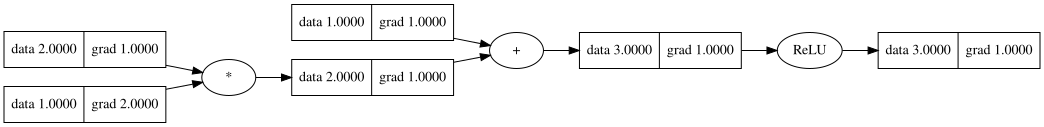

In [ ]:
# a very simple example
x = Scalar(1.0)
y = (x * 2 + 1).tanh()
y.backward()
draw_dot(y)